## **Динамика лексических характеристик в романе Л.Н. Толстого «Анна Каренина»**

**Актуальность.**

В гуманитарных науках все большее значение приобретают цифровые методы, которые позволяют выявить скрытые закономерности в текстах на основе их количественного анализа. В последние годы произведения Л.Н. Толстого плодотворно изучаются в рамках Digital Humanities. В частности, в свете векторных моделей рассматривалась индивидуальная семантика автора, а с помощью лексико-статистических методов его творчество сопоставлялось с творчеством современных ему писателей. Нередко объектом исследований становился роман «Война и мир»: сегодня можно найти работы, посвященные анализу речи героев романа с применением методов стилометрии, выявлению иерархии персонажей и характера их взаимоотношений с помощью сетевого анализа, изучению пространства и перемещения героев с применением цифрового картографирования. Однако для романа «Анна Каренина» подобных исследований найдено не было, с точки зрения количественной динамики лексики это произведение не рассматривалось.

**Цель работы** – выявить и описать динамику лексических характеристик в романе Л.Н. Толстого «Анна Каренина» с помощью статистических методов. В качестве **материала** для проведения исследования взят текст романа, разделенный на восемь частей в соответствии с оригинальной структурой произведения.

**Гипотеза** заключается в том, что лексические характеристики частей романа не являются однородными, то есть между ними существуют статистически значимые различия, которые можно связать с сюжетной линией произведения.

Для достижения цели и проверки гипотезы поставлены следующие **задачи**:

1.	Выполнить предварительную обработку текста.
2.	Получить описательную статистику для каждой части произведения.
3.	Отобрать значимые для сюжета слова и проанализировать их распределение по тексту романа.
4.	Сгруппировать части по лексическому сходству.
5.	Интерпретировать результаты и сделать вывод о наличии или отсутствии лексической динамики в романе.  

В качестве основного **метода** используется один из вариантов многомерного анализа данных – кластерный анализ. Его основная идея состоит в разделении текста на отдельные группы, в которые попадают множества объектов, близких друг к другу по своим свойствам. В настоящей работе для определения наиболее близких и далеких по лексическим характеристикам частей романа «Анна Каренина» применен метод Джо Уорда. Кластерный анализ ранее применялась для анализа художественных произведений, а одним из преимуществ этого метода можно назвать относительную объективность характеристик текста, поскольку кластерный анализ предполагает исследование не отдельных лексических единиц текста, а целостных лексических полей.

### **Подготовка к работе**

In [3]:
! pip install pymorphy3 pandas numpy matplotlib scipy # устанавливаем библиотеки

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.9/53.9 kB 802.5 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 15.7 MB/s eta 0:00:00


In [6]:
# стандартные библиотеки для работы с текстом и данными
import re
from collections import Counter

# библиотеки для анализа данных
import numpy as np
import pandas as pd

# библиотеки для визуализации
import matplotlib.pyplot as plt
import matplotlib

# библиотеки для кластерного анализа
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist, squareform

# библиотека для лемматизации
import pymorphy3

# настройка шрифта для корректного отображения кириллицы на графиках
matplotlib.rcParams['font.family'] = 'DejaVu Sans'

In [7]:
# путь к восьми частям романа
PART_FILES  = [f"part_{i}.txt" for i in range(1, 9)]
PART_LABELS = [f"Часть {i}" for i in range(1, 9)]

In [8]:
# загружаем каждую часть романа в список texts
texts = []

for i, filepath in enumerate(PART_FILES):
    with open(filepath, encoding="utf-8") as f:
        text = f.read()
    texts.append(text)
    print(f"Часть {i+1}: загружено {len(text.split())} слов") # длина глав

Часть 1: загружено 39855 слов
Часть 2: загружено 41404 слов
Часть 3: загружено 40564 слов
Часть 4: загружено 28431 слов
Часть 5: загружено 39957 слов
Часть 6: загружено 39972 слов
Часть 7: загружено 33975 слов
Часть 8: загружено 16399 слов


### **Предварительная обработка текста**

In [9]:
def clean_text(text):
    text = text.lower() # приводим текст к нижнему регистру
    text = re.sub(r"[^а-яё\s]", " ", text)  # убираем все кроме русских букв
    words = text.split()
    words = [w for w in words if len(w) >= 2]  # убираем слова короче двух символов (предлоги, союзы)
    return words

cleaned_texts = [clean_text(t) for t in texts]

for i, words in enumerate(cleaned_texts):
    print(f"Часть {i+1}: {len(words)} слов после очистки") # длина глав после очистки

Часть 1: 33773 слов после очистки
Часть 2: 35277 слов после очистки
Часть 3: 34998 слов после очистки
Часть 4: 24138 слов после очистки
Часть 5: 34440 слов после очистки
Часть 6: 33779 слов после очистки
Часть 7: 28784 слов после очистки
Часть 8: 14083 слов после очистки


In [10]:
# стоп-слова — служебные слова, местоимения, частые наречия и вводные слова
# они не несут смысловой нагрузки и могут исказить частотный анализ, поэтому убираем их
STOPWORDS = {
    "и", "в", "не", "он", "на", "я", "что", "тот", "быть", "с", "а", "весь",
    "это", "как", "она", "по", "но", "они", "к", "у", "ты", "из", "мы",
    "за", "то", "свой", "ещё", "бы", "его", "до", "вы", "от", "меня",
    "при", "об", "же", "или", "чтобы", "себя", "ни", "со", "тоже",
    "уже", "если", "так", "о", "для", "когда", "всё", "здесь",
    "там", "потом", "теперь", "тут", "только", "очень", "даже",
    "вот", "нет", "да", "ну", "вдруг", "всегда", "конечно", "именно",
    "просто", "совсем", "совершенно", "неужели", "будто", "хотя", "ведь",
    "разве", "кажется", "значит", "впрочем", "наверное",
    "который", "которая", "которое", "которые", "чей", "чья", "чьё",
    "один", "этот", "та", "те", "этого", "этой", "этих", "этому",
    "него", "ней", "них", "ним", "нему", "им", "их", "ему", "её",
    "мне", "нам", "вам", "нас", "вас", "моя", "мой", "моё", "мои",
    "твой", "твоя", "твоё", "твои", "наш", "наша", "наше", "наши",
    "ваш", "ваша", "ваше", "ваши", "себе", "сам", "сама", "само",
    "сами", "между", "через", "после", "перед", "под", "над", "про",
    "без", "до", "около", "среди", "вместе", "где", "куда", "откуда",
    "потому", "поэтому", "однако", "также", "кроме", "чем", "чего"
}

filtered_texts = [
    [w for w in words if w not in STOPWORDS]
    for words in cleaned_texts
]

for i, words in enumerate(filtered_texts):
    print(f"Часть {i+1}: {len(words)} слов после удаления стоп-слов") # длина глав после удаления стоп-слов

Часть 1: 23384 слов после удаления стоп-слов
Часть 2: 24517 слов после удаления стоп-слов
Часть 3: 24271 слов после удаления стоп-слов
Часть 4: 16491 слов после удаления стоп-слов
Часть 5: 23589 слов после удаления стоп-слов
Часть 6: 23408 слов после удаления стоп-слов
Часть 7: 19442 слов после удаления стоп-слов
Часть 8: 9704 слов после удаления стоп-слов


In [11]:
# лемматизация — приведение слов к начальной форме, используем библиотеку pymorphy3 для русского языка

morph = pymorphy3.MorphAnalyzer()

# cловарь исключений для слов которые pymorphy3 лемматизирует неправильно
EXCEPTIONS = {
    "кити": "кити",
    "покровское": "покровское",
    "воздвиженское": "воздвиженское",
}

def lemmatize(words):
    result = []
    for w in words:
        if w in EXCEPTIONS:
            lemma = EXCEPTIONS[w]
        else:
            lemma = morph.parse(w)[0].normal_form
        if lemma not in STOPWORDS:
            result.append(lemma)
    return result

lemmas_list = []

for i, words in enumerate(filtered_texts):
    lemmas = lemmatize(words)
    lemmas_list.append(lemmas)
    print(f"Часть {i+1}: {len(lemmas)} лемм") # длина глав после лемматизации

Часть 1: 20775 лемм
Часть 2: 21829 лемм
Часть 3: 21577 лемм
Часть 4: 14660 лемм
Часть 5: 20785 лемм
Часть 6: 20807 лемм
Часть 7: 17209 лемм
Часть 8: 8660 лемм


In [12]:
lemma_counts = [len(l) for l in lemmas_list] # итоговая таблица предобработки

df_preproc = pd.DataFrame({
    "Часть":              range(1, 9),
    "Исходных слов":      [len(t.split()) for t in texts],
    "После очистки":      [len(w) for w in cleaned_texts],
    "После лемматизации": lemma_counts,
})

print(df_preproc.to_string(index=False))

 Часть  Исходных слов  После очистки  После лемматизации
     1          39855          33773               20775
     2          41404          35277               21829
     3          40564          34998               21577
     4          28431          24138               14660
     5          39957          34440               20785
     6          39972          33779               20807
     7          33975          28784               17209
     8          16399          14083                8660


В **результате** предварительной обработки получено восемь очищенных глав, состоящих из лемматизированных и статистически значимых слов. Очищенные главы будут использованя для подсчета описательной статистики и дальнейшей кластеризации.

### **Описательная статистика**

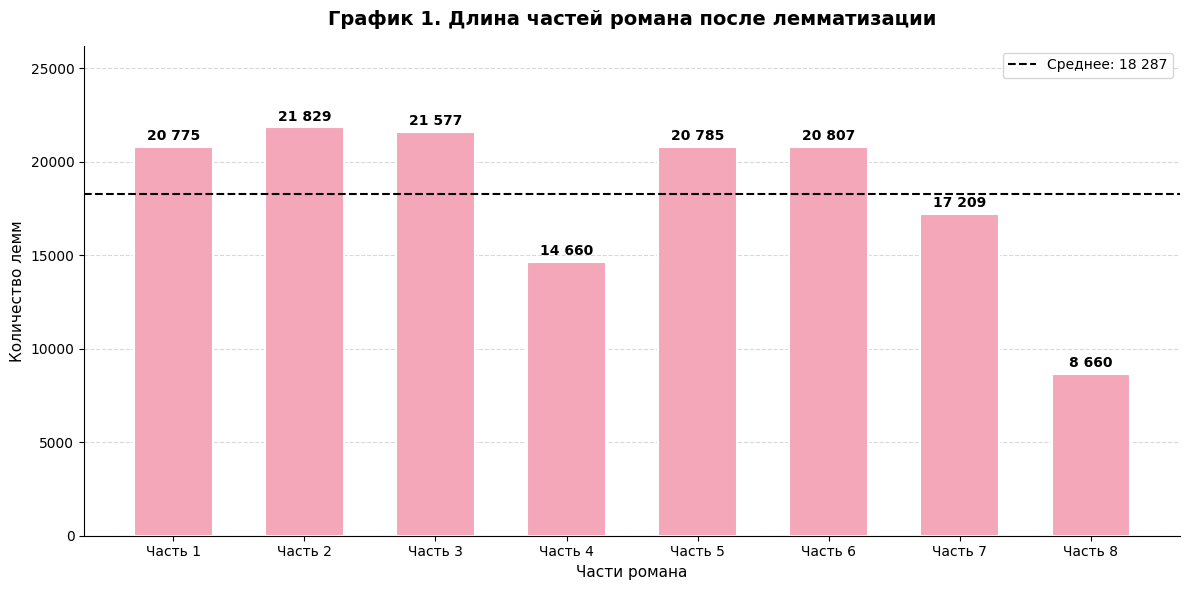

In [13]:
# столбчатая диаграмма длин частей после лемматизации

fig, ax = plt.subplots(figsize=(12, 6))

# розовые столбцы с белой обводкой
bars = ax.bar(PART_LABELS, lemma_counts, color="#f4a7b9",
              edgecolor="white", linewidth=1.5, width=0.6)

# сетка
ax.set_axisbelow(True)
ax.yaxis.grid(True, color="grey", linestyle="--", alpha=0.3)

# подписи значений над столбцами
for bar, v in zip(bars, lemma_counts):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 200,
        f"{v:,}".replace(",", " "),
        ha="center", va="bottom",
        fontsize=10, fontweight="bold", color="black"
    )

# средняя линия
mean_val = sum(lemma_counts) / len(lemma_counts)
ax.axhline(mean_val, color="black", linestyle="--",
           linewidth=1.5, label=f"Среднее: {int(mean_val):,}".replace(",", " "))

# заголовок и подписи осей
ax.set_title("График 1. Длина частей романа после лемматизации",
             fontsize=14, fontweight="bold", pad=15)
ax.set_ylabel("Количество лемм", fontsize=11)
ax.set_xlabel("Части романа", fontsize=11)

# запас сверху чтобы подписи над столбцами не обрезались
ax.set_ylim(0, max(lemma_counts) * 1.2)

# легенда для линии среднего
ax.legend(fontsize=10)

# убираем верхнюю и правую рамки
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

**Объем частей романа после предобработки** варьируется от 8660 лемм (часть 8) до 21829 лемм (часть 2). Части 1-3 и 5-6 имеют сопоставимый размер (около 21000 лемм), тогда как части 4 и 7 несколько меньше других (14660 и 17209 лемм соответственно), а часть 8 выделяется как самая короткая. Этот разброс в объеме необходимо учитывать при последующей работе с корпусом и интерпретации статистических значений. Особенно важно обратить внимание на неравномерность длин частей романа при проведении кластеризации, так как использование абсолютных частот может исказить результаты.

In [14]:
# лексическая плотность показывает разнообразие словаря в каждой части, чем выше — тем богаче лексика

lex_density = [len(set(l)) / len(l) for l in lemmas_list] # лексическая плотность = уникальных лемм / всего лемм

df_density = pd.DataFrame({
    "Часть":                 range(1, 9),
    "Лексическая плотность": [round(d, 3) for d in lex_density],
})

print(df_density.to_string(index=False))

 Часть  Лексическая плотность
     1                  0.217
     2                  0.219
     3                  0.236
     4                  0.243
     5                  0.218
     6                  0.224
     7                  0.229
     8                  0.335


**Лексическая плотность** на основном протяжении романа находится на одном уровне в пределах 0,217–0,243. Исключением можно назвать последнюю часть романа (часть 8), она характеризуется самым высоким показателем – 0,335, что объясняется ее малым объёмом, из-за которого повторяемость слов не успевает накопиться. Кроме того, в этой части заметен переход от большего количества диалогов к большему количеству монологов. В финале произведения Константин Левин размышляет о религии, находит свой смысл жизни. Возможно, эта рефлексия также повлияла на лексическое разнообразие в заключительной части романа.

In [15]:
# строим счетчики частот для каждой части и для всего корпуса
# сounter — словарь вида {слово: количество вхождений}
# нужен для всех последующих расчетов

counters = [Counter(l) for l in lemmas_list]
total_counter = Counter()
for c in counters:
    total_counter.update(c)

print(f"Всего уникальных лемм в корпусе: {len(total_counter)}")

Всего уникальных лемм в корпусе: 12680


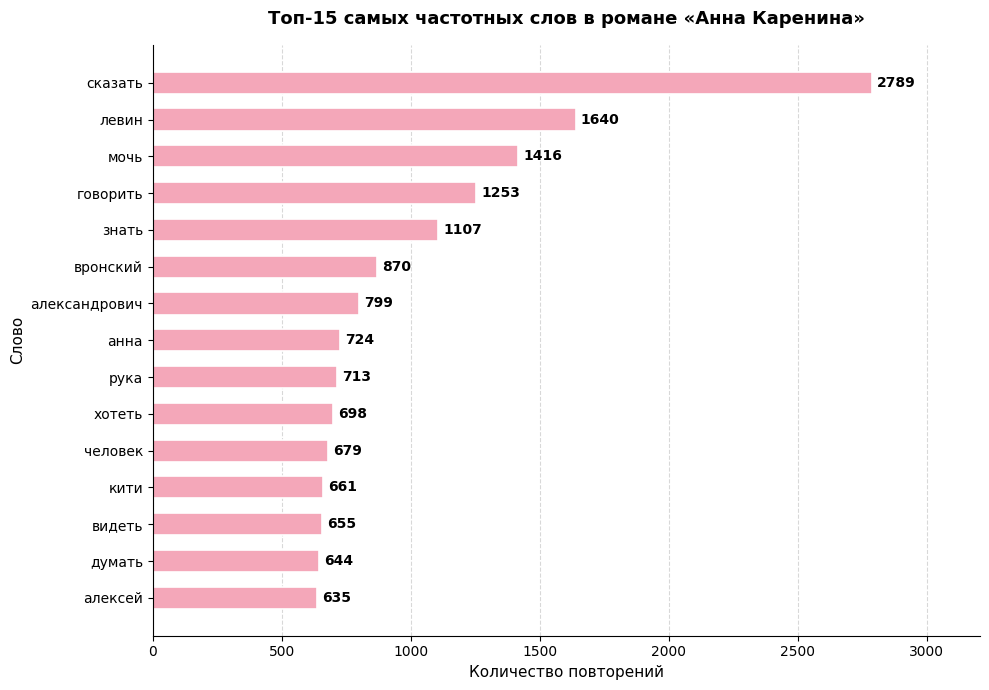

In [16]:
# топ-15 самых частотных слов — горизонтальная столбчатая диаграмма

top15 = total_counter.most_common(15)
words = [w for w, _ in top15]
counts = [c for _, c in top15]

fig, ax = plt.subplots(figsize=(10, 7))

# розовые столбцы, перевернуты чтобы топ-1 был сверху
bars = ax.barh(words[::-1], counts[::-1], color="#f4a7b9",
               edgecolor="white", linewidth=1.2, height=0.6)

# подписи значений справа от каждого столбца
for bar, v in zip(bars, counts[::-1]):
    ax.text(
        bar.get_width() + 20,
        bar.get_y() + bar.get_height() / 2,
        str(v),
        va="center", fontsize=10, fontweight="bold", color="black"
    )

# сетка
ax.set_axisbelow(True)
ax.xaxis.grid(True, color="grey", linestyle="--", alpha=0.3)

# подписи осей и заголовок
ax.set_title("Топ-15 самых частотных слов в романе «Анна Каренина»",
             fontsize=13, fontweight="bold", pad=15)
ax.set_xlabel("Количество повторений", fontsize=11)
ax.set_ylabel("Слово", fontsize=11)
ax.set_xlim(0, max(counts) * 1.15)

# убираем лишние рамки
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

Среди наиболее частотных слов встречаются **глаголы речи** («сказать», «говорить»), **глаголы мышления **(«знать», «думать»), **глагол возможности** («мочь»), **глагол желания** («хотеть»), а также **глагол восприятия** («видеть»). Это закономерно, поскольку структура художественного произведения предполагает наличие как диалогов между персонажами, так и монологов, помогающих передать их внутреннее состояние.

Помимо глаголов в выборку попали **имена главных героев произведения**: Левин, Вронский, Анна, Кити. Важно заметить, что кроме этих имён собственных по отношению к героям используются и другие (например, Анну также называют «Каренина», Вронского — «Алексей Кириллович», Левина — «Костя» или «Константин Дмитриевич», Кити — «Катя» или «княжна Щербацкая» и др.), поэтому точное количество упоминаний героев подсчитать сложно. Кроме того, в процессе лемматизации слова приводятся к начальной форме, поэтому под словом «Левин» может скрываться как Константин, так и Кити, ставшая в замужестве Левиной, а под словом «Вронский» — Алексей или его мать, графиня Вронская.

Отдельного внимания заслуживает присутствие в топ-15 слова «александрович» и «алексей» — отчество и имя, которые в романе относятся одновременно к двум персонажам, а именно Каренину и Вронскому, что затрудняет их разграничение при частотном анализе.

Из общей тенденции видно, что **Левин является самым частотным персонажем, за ним следуют Вронский, Анна и Кити**.

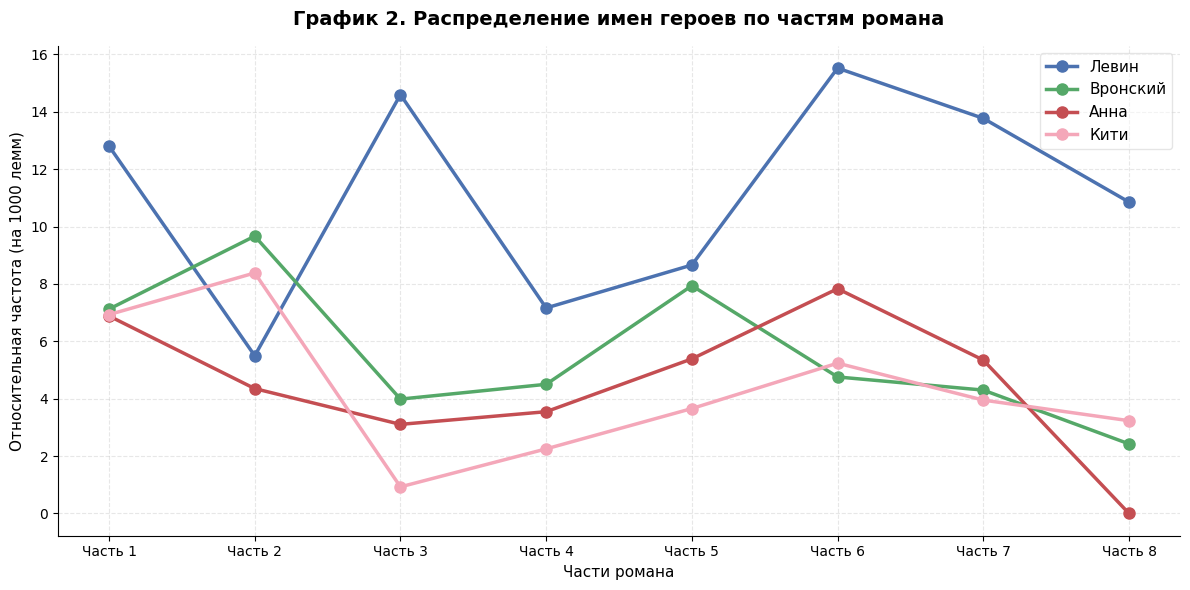

In [36]:
# смотрим на расспределение имен героев по частям романа

HEROES = ["левин", "вронский", "анна", "кити"]

# цвета для каждого героя
hero_colors = {
    "левин":    "#4C72B0",
    "вронский": "#55A868",
    "анна":     "#C44E52",
    "кити":     "#f4a7b9",
}

fig, ax = plt.subplots(figsize=(12, 6))

for word in HEROES:
    # относительная частота = количество упоминаний / длина части * 1000
    # нормировка на 1000 лемм нужна чтобы части разной длины были сопоставимы
    freqs = [counters[i].get(word, 0) / lemma_counts[i] * 1000
             for i in range(8)]
    ax.plot(PART_LABELS, freqs,
            marker="o",       # точка на каждой части
            markersize=8,     # размер точки
            linewidth=2.5,    # толщина линии
            color=hero_colors[word],
            label=word.capitalize())  # заглавная буква в легенде

# заголовок и подписи осей
ax.set_title("График 2. Распределение имен героев по частям романа",
             fontsize=14, fontweight="bold", pad=15)
ax.set_ylabel("Относительная частота (на 1000 лемм)", fontsize=11)
ax.set_xlabel("Части романа", fontsize=11)

# легенда с полупрозрачным фоном
ax.legend(fontsize=11, framealpha=0.5)

# пунктирная сетка
ax.grid(True, alpha=0.3, linestyle="--")

# убираем верхнюю и правую рамки
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

Произведение носит имя Анны Карениной, но в центре повествования Л. Н. Толстого остается Константин Левин, его кривая достигает пиковых значений в **частях 3 и 6**, что соотносится с ключевыми событиями жизни героя – отъездом в деревню после отказа Кити и рождением их сына. Лишь во **2-й части** упоминание Левина уступает по частотности упоминаниям Вронского и Кити, что объясняется историей их несостоявшегося союза и последующей душевной болезнью девушки.

Кривая Анны демонстрирует умеренные значения в первой половине романа, постепенно нарастает к **6-й части** и резко падает до минимума в **8-й части**, то есть после смерти героиня практически не упоминается.

Интересно, что **часть 5** является наиболее сбалансированной по частотности имен героев. По сюжету в ней одновременно происходят два равнозначных для сюжетных линий события – венчание Левина и Кити и отъезд Анны с Вронским в Италию.

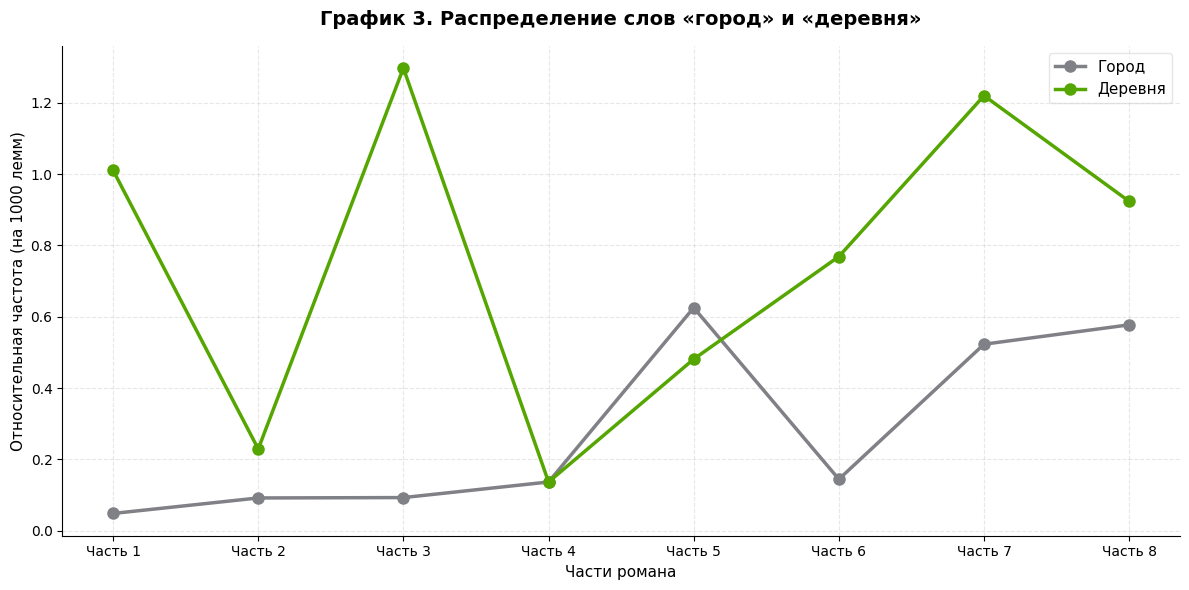

In [20]:
# распределение слов «город» и «деревня» по частям романа
# отражает оппозицию город-деревня — одну из ключевых тем романа

CITY_RURAL = ["город", "деревня"]

# цвета
city_colors = {
    "город":   "#808087",
    "деревня": "#55A600",
}

fig, ax = plt.subplots(figsize=(12, 6))

for word in CITY_RURAL:
    # относительная частота на 1000 лемм для сопоставимости частей
    freqs = [counters[i].get(word, 0) / lemma_counts[i] * 1000
             for i in range(8)]
    ax.plot(PART_LABELS, freqs,
            marker="o",
            markersize=8,
            linewidth=2.5,
            color=city_colors[word],
            label=word.capitalize())

# заголовок и подписи осей
ax.set_title("График 3. Распределение слов «город» и «деревня»",
             fontsize=14, fontweight="bold", pad=15)
ax.set_ylabel("Относительная частота (на 1000 лемм)", fontsize=11)
ax.set_xlabel("Части романа", fontsize=11)

# легенда с полупрозрачным фоном
ax.legend(fontsize=11, framealpha=0.5)

# сетка
ax.grid(True, alpha=0.3, linestyle="--")

# убираем верхнюю и правую рамки
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

Графики распределения слов **«город»** и **«деревня»** фиксируют оппозицию «город - деревня», которая является одной из ключевых в романе. Лексема «деревня» значительно преобладает над лексемой «город» в **частях 3 и 7**, а также в **части 8**, что соотносится с переездом Левина в Покровское и его семейной жизнью в имении в финале романа.

В **части 5**, напротив, кривые почти совпадают, что может отражать одновременное разворачивание городской и деревенской сюжетных линий.   Примечательно, что в **части 4** обе лексемы достигают минимальных значений, возможно, это связано с тем, что действие этой части сосредоточено на внутренних переживаниях героев, а не на пространственных перемещениях.

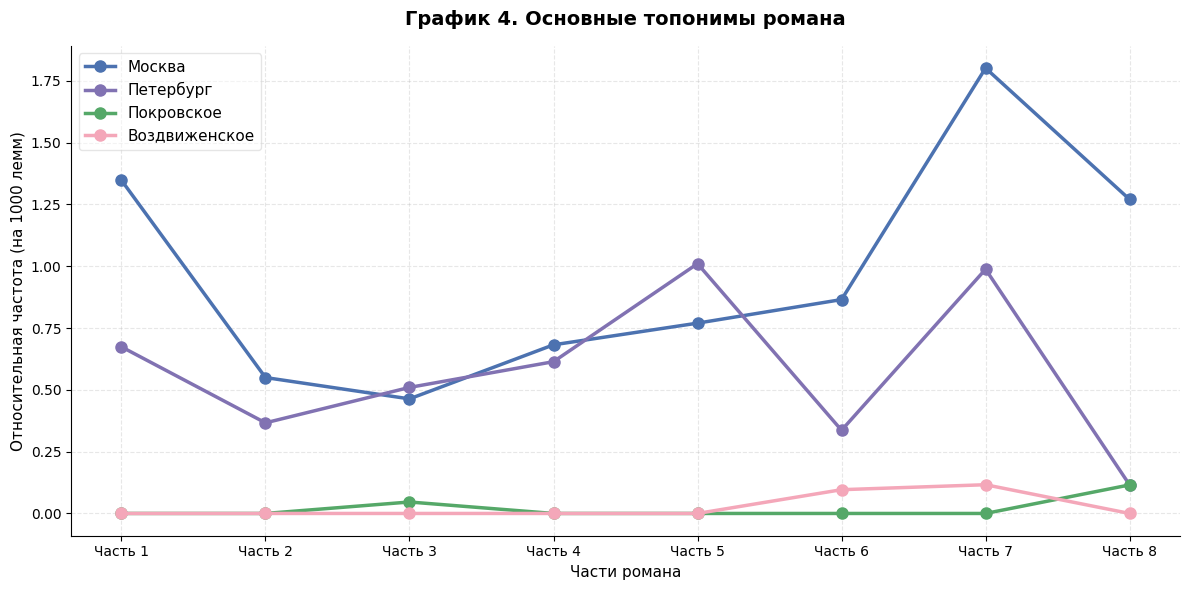

In [21]:
# распределение основных топонимов по частям романа
# показывает где географически разворачивается действие в каждой части
TOPONYMS = ["москва", "петербург", "покровское", "воздвиженское"]

# цвета
toponym_colors = {
    "москва":         "#4C72B0",
    "петербург":      "#8172B2",
    "покровское":     "#55A868",
    "воздвиженское":  "#f4a7b9",
}

fig, ax = plt.subplots(figsize=(12, 6))

for word in TOPONYMS:
    # относительная частота на 1000 лемм для сопоставимости частей
    freqs = [counters[i].get(word, 0) / lemma_counts[i] * 1000
             for i in range(8)]
    ax.plot(PART_LABELS, freqs,
            marker="o",
            markersize=8,
            linewidth=2.5,
            color=toponym_colors[word],
            label=word.capitalize())

# заголовок и подписи осей
ax.set_title("График 4. Основные топонимы романа",
             fontsize=14, fontweight="bold", pad=15)
ax.set_ylabel("Относительная частота (на 1000 лемм)", fontsize=11)
ax.set_xlabel("Части романа", fontsize=11)

# легенда с полупрозрачным фоном
ax.legend(fontsize=11, framealpha=0.5)

# сетка
ax.grid(True, alpha=0.3, linestyle="--")

# убираем верхнюю и правую рамки
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

Среди выбранных **топонимов** на протяжении всего романа преобладают Москва и Петербург, тогда как названия усадеб сохраняют относительно низкую частотность. Покровское показывает заметный подъем в **части 8**, где повествование сосредотачивается на Левине и его семейной жизни в имении. У Воздвиженского наблюдается небольшой пик **в части 6-7**, что соответствует пребыванию Анны и Вронского в его имении.

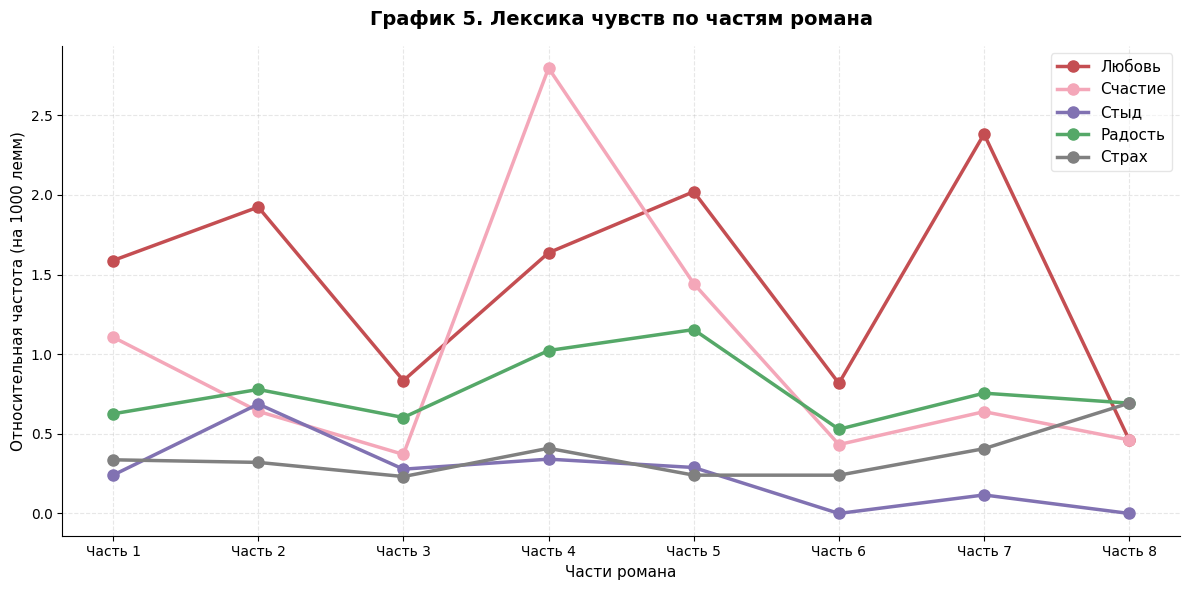

In [22]:
# распределение лексики чувств по частям романа

FEELINGS = ["любовь", "счастие", "стыд", "радость", "страх"]

# цвета
feelings_colors = {
    "любовь":  "#C44E52",
    "счастие": "#f4a7b9",
    "стыд":    "#8172B2",
    "радость": "#55A868",
    "страх":   "#808080",
}

fig, ax = plt.subplots(figsize=(12, 6))

for word in FEELINGS:
    # относительная частота на 1000 лемм для сопоставимости частей
    freqs = [counters[i].get(word, 0) / lemma_counts[i] * 1000
             for i in range(8)]
    ax.plot(PART_LABELS, freqs,
            marker="o",
            markersize=8,
            linewidth=2.5,
            color=feelings_colors[word],
            label=word.capitalize())

# заголовок и подписи осей
ax.set_title("График 5. Лексика чувств по частям романа",
             fontsize=14, fontweight="bold", pad=15)
ax.set_ylabel("Относительная частота (на 1000 лемм)", fontsize=11)
ax.set_xlabel("Части романа", fontsize=11)

# легенда с полупрозрачным фоном
ax.legend(fontsize=11, framealpha=0.5)

# сетка
ax.grid(True, alpha=0.3, linestyle="--")

# убираем верхнюю и правую рамки
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

График распределения **лексики чувств** позволяет проследить эмоциональную динамику романа.

Лексема **«любовь»** преобладает над другими почти на протяжении всего текста, однако ее кривая неоднородна: первый пик приходится на **часть 2**, где разворачивается роман Анны и Вронского, затем следует спад, второй более высокий пик приходится на **часть 7**. Он совпадает с кульминацией и гибелью героини.

Также примечательна кривая **«счастия»**. Она резко возрастает **в части 4** и достигает там максимального значения среди всех представленных лексем, что соотносится с событиями этой части – примирением Левина с Кити и предложением руки, а также уходом Анны от мужа.

**«Стыд»** более частотен в **2-й части**, что может отражать как реакцию героев на отказ Вронского от женитьбы на Кити, так и начало запретного романа и реакцию общества на поведение Анны.

Кривые **«радости»** и **«страха»** сохраняют относительно низкие и стабильные значения на протяжении всего романа, незначительно возрастая в частях 4-5. Вероятно, они не отражают реальных тенденций.

Таким образом, график лексики чувств позволяет зафиксировать **эмоциональные пики в частях 4 и 7**.

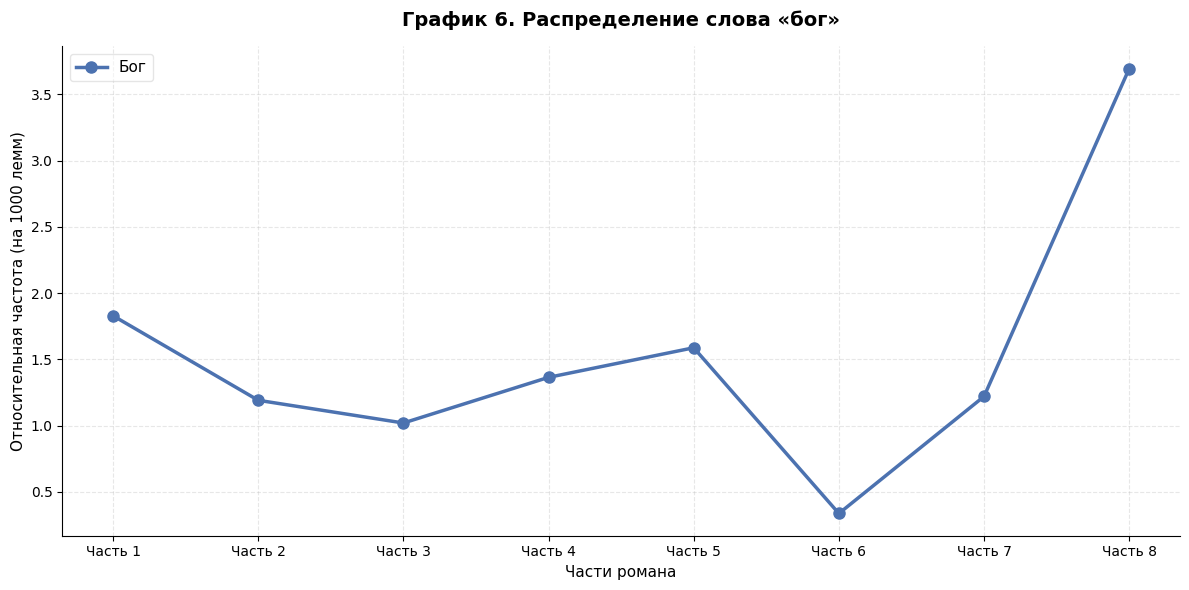

In [23]:
# распределение слова «бог» по частям романа

RELIGION = ["бог"]

fig, ax = plt.subplots(figsize=(12, 6))

for word in RELIGION:
    # относительная частота на 1000 лемм для сопоставимости частей
    freqs = [counters[i].get(word, 0) / lemma_counts[i] * 1000
             for i in range(8)]
    ax.plot(PART_LABELS, freqs,
            marker="o",
            markersize=8,
            linewidth=2.5,
            color="#4C72B0",
            label=word.capitalize())

# заголовок и подписи осей
ax.set_title("График 6. Распределение слова «бог»",
             fontsize=14, fontweight="bold", pad=15)
ax.set_ylabel("Относительная частота (на 1000 лемм)", fontsize=11)
ax.set_xlabel("Части романа", fontsize=11)

# легенда с полупрозрачным фоном
ax.legend(fontsize=11, framealpha=0.5)

# сетка
ax.grid(True, alpha=0.3, linestyle="--")

# убираем верхнюю и правую рамки
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

График распределения лексемы **«бог»** отражает динамику религиозно-философской линии романа. В части 1 наблюдается относительно высокая частотность, после чего она снижается и сохраняет стабильные значения вплоть до части 5. Небольшой подъем в **части 5** соотносится со смертью брата Левина — эпизодом, где герой напрямую сталкивается с вопросами веры. Резкое падение до минимального значения в **части 6** объясняется тем, что повествование в этой части сосредоточено преимущественно на бытовой жизни героев и светских сценах. Примечательно, что уже в части 7 начинается постепенный рост, который завершается резким и значительным подъемом в **части 8**, где частотность достигает максимума за весь роман и почти вдвое превышает все предыдущие значения. Именно в этой части Левин приходит к вере и находит для себя смысл жизни. График в целом подтверждает, что религиозная тематика нарастает постепенно и достигает кульминации в финале, превращая роман о любви в роман о нравственном обретении.

### **Кластеризация методом Джо Уорда**

Для кластерного анализа строим матрица евклидовых расстояний на основе относительных частот топ-100 лемм корпуса. Евклидово расстояние измеряет лексическое сходство частей: чем меньше значение, тем ближе части по словарному составу.

In [34]:
# матрица евклидовых расстояний между частями романа

# берем топ-100 самых частотных лемм по всему корпусу
top100_words = [w for w, _ in total_counter.most_common(100)]

# строим матрицу относительных частот: строки = части, столбцы = слова
rel_freq_matrix = np.zeros((8, 100))
for i, counter in enumerate(counters):
    for j, word in enumerate(top100_words):
        # относительная частота = количество вхождений / длина части
        rel_freq_matrix[i, j] = counter.get(word, 0) / lemma_counts[i]

# вычисляем евклидово расстояние между каждой парой частей
dist_matrix = squareform(pdist(rel_freq_matrix, metric="euclidean"))

# оформляем в таблицу с подписями частей
df_dist = pd.DataFrame(
    np.round(dist_matrix, 6),
    index=PART_LABELS,
    columns=PART_LABELS
)

print("Таблица 4. Матрица евклидовых расстояний:")
print(df_dist.to_string())

Таблица 4. Матрица евклидовых расстояний:
          Часть 1   Часть 2   Часть 3   Часть 4   Часть 5   Часть 6   Часть 7   Часть 8
Часть 1  0.000000  0.014406  0.017527  0.024937  0.013920  0.012844  0.011532  0.024068
Часть 2  0.014406  0.000000  0.018169  0.021802  0.011488  0.017544  0.016087  0.025659
Часть 3  0.017527  0.018169  0.000000  0.024285  0.012675  0.013922  0.016725  0.019496
Часть 4  0.024937  0.021802  0.024285  0.000000  0.021839  0.025176  0.021096  0.033539
Часть 5  0.013920  0.011488  0.012675  0.021839  0.000000  0.015691  0.015231  0.021927
Часть 6  0.012844  0.017544  0.013922  0.025176  0.015691  0.000000  0.012598  0.022423
Часть 7  0.011532  0.016087  0.016725  0.021096  0.015231  0.012598  0.000000  0.024893
Часть 8  0.024068  0.025659  0.019496  0.033539  0.021927  0.022423  0.024893  0.000000


Перед построением кластеров важно выбрать способ их объединения. Для текущей работы оптимальным представляется метод, в котором расстояние между двумя кластерами определяется расстоянием между двумя ближайшими объектами. При построении иерархического кластера используется м**етод Джо Уорда**, который предполагает включение объекта в кластер на основе минимума дисперсии внутри кластера между объектами. Низкая дисперсия является показателем близости значений. Этот метод выбран и потому, что он применяется при расчете евклидового расстояния как меры различия между частями текста.

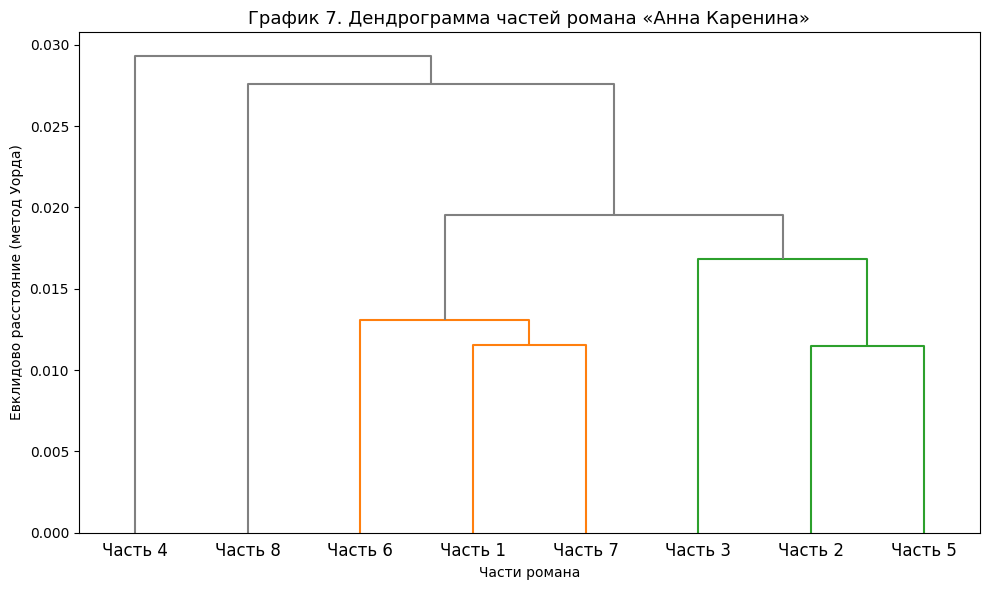

In [35]:
# иерархическая кластеризация методом Уорда

# строим матрицу связей для дендрограммы
Z = linkage(rel_freq_matrix, method="ward", metric="euclidean")
fig, ax = plt.subplots(figsize=(10, 6))
dendrogram(
    Z,
    labels=PART_LABELS,
    ax=ax,
    color_threshold=0.6 * max(Z[:, 2]),
    above_threshold_color="grey",
)
# заголовок и подписи осей
ax.set_title("График 7. Дендрограмма частей романа «Анна Каренина»", fontsize=13)
ax.set_ylabel("Евклидово расстояние (метод Уорда)")
ax.set_xlabel("Части романа")
plt.tight_layout()
plt.show()

# убираем верхнюю и правую рамки
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

Дендрограмма показывает, что образуется две группы частей со схожей лексикой — это **кластер частей 2, 3, 5** (зеленый) и **кластер частей 1, 6, 7** (оранжевый).

Интерпретация причин такого распределения субъективна, но представляется важным обозначить некоторые закономерности.

Внутри **зеленого кластера** части 2 и 5 объединяются первыми на относительно небольшом расстоянии, что указывает на их наибольшее лексическое сходство между собой. Часть 3 присоединяется к ним позже и на большем расстоянии, то есть она несколько отличается от двух других, но в целом тяготеет к той же лексической группе. Все три части объединяет преимущественно деревенская и усадебная тематика — Левин, Покровское, хозяйственная жизнь. Для частей, объединившихся во **оранжевый кластер**, характерна преимущественно противоположная тематика. Все три части городские и светские по своему содержанию, что отличает их от частей 3 и 5.

Важно заметить, что **части 4 и 8** не вошли ни в один из кластеров. На это могло повлиять сочетание нескольких сюжетных линий в одной части и особая тематика другой. По сюжету часть 4 можно назвать переломной, так как в ней происходят развязка брака Карениных, уход Анны к Вронскому и примирение Левина с Кити. Часть 8 выделяется по иной причине – она посвящена духовным размышлениям Левина и насыщена религиозной и философской лексикой. Возможно, этим объясняется некоторая «изолированность» частей.


### **Заключение**

В работе была предпринята попытка выявить и описать динамику лексических характеристик романа Л. Н. Толстого «Анна Каренина» с описательной статистики и иерархической кластеризации.

1. **Гипотеза** о том, что части романа не являются однородными и между лексикой существуют статистически значимые различия, **нашла подтверждение**.

2. Описательная статистика показала, что среди имен главных героев наибольшую частотность на протяжении романа сохраняет Левин, что подтверждает его роль как идейного центра произведения.

3. Распределение «города» и «деревни» зафиксировало оппозицию двух лексем как значимую характеристику динамики текста.

4. Анализ лексики чувств позволил выявить два эмоциональных пика романа в частях 4 и 7, что соотносится с сюжетными линиями романа.

5. Динамика лексемы «бог» подтвердила, что религиозная тематика нарастает постепенно и достигает кульминации в финальной части.

6. Кластерный анализ выявил два лексических кластера – части 2, 3, 5 и части 1, 6, 7. При этом части 4 и 8 не вошли ни в один из кластеров.

Следует отметить, что проведенное исследование имеет **ряд ограничений**. Кластеризация основана на 100 наиболее частотных словах, что оставляет за рамками анализа менее частотную, но тематически значимую лексику. Выбор метода объединения кластеров влияет на итоговую группировку, применение других методов могло бы дать иные результаты.

Однако перечисленные ограничения не опровергают полученные результаты, а открывают **перспективы для дальнейшего исследования**. Так, в будещем мне бы хотелось разделить текст романа на прямую речи и монологи героев, чтобы на основе каждого персонажа можно было составить лексический портрет. Было бы интересно провести сравнительной количественный анализ двух центральных женских образов —
 Кити и Анны.

**Список источников и литературы**

**Источники**

1.	Толстой Л.Н. «Анна Каренина» // RoyalLib. URL: https://royallib.com/book/tolstoy_lev/anna_karenina.html?ysclid=mpvm4v5731174458440 (дата обращения: 29.05.2026).

**Литература**

1.	Абдина Р. П. Кластерный анализ в исследовании экзотизмов художественных текстов // Известия ВГПУ. – 2013. – №4. – С. 102-104.
2.	Котович Н. В. Алгоритмы кластеризации образов символов // Труды ИСА РАН. – 2008. – №38. – С. 241-251.
3.	Курьянова В. В., Павленко Е. С. Городской и деревенский топосы в романе Л. Н. Толстого «Анна Каренина» // История русской литературы. – 2018. - №2. – С. 3-15.
4.	Мухин М. Ю., Мухин Н. Ю. «Шаги» персонажей в прозе Л. Н. Толстого и его современников: сопоставительное статистическое исследование авторской лексической сочетаемости // Cuadernos de Rusística Española. – 2021. – Т. 17. – С. 67-76.
5.	Орехов Б. В. Индивидуальная семантика Л. Н. Толстого в свете векторных моделей // Terra Linguistica. – 2023. – Т. 14. – №4. – С. 119-129.
6.	Хорошева Н. В., Мадей Е. Д. Актуализация эмотивных смыслов в переводах пьес А. П. Чехова: кластерный подход // Язык и культура. – 2023. – №63. – С. 77-99.
7.	Kokobobo A. Using digital technologies to uncover the geographic dimension of Tolstoy’s War and Peace // Russian Literature. – 2021. – Vol. 122-123. – P. 193-215.
8.	Murtagh F., Legendre P. Ward’s Hierarchical Agglomerative Clustering Method: Which Algorithms Implement Ward’s Criterion? // Journal of Classification . – 2014. – №31. – P. 274-295.
9.	Гид по Voyant Tools: подготовка корпуса // Системный блокъ. URL: https://sysblok.ru/philology/gid-po-voyant-tools-podgotovka-korpusa/ (дата обращения: 29.05.2026).
10.	500 героев в одной схеме: о чем говорит сетевой анализ «Войны и мира» // Системный блокъ. URL: https://sysblok.ru/philology/500-geroev-v-odnoj-sheme-o-chem-govorit-setevoj-analiz-vojny-i-mira/ (дата обращения: 29.05.2026).
11.	Что говорит о персонажах «Войны и мира» их речь // Системный блокъ. URL: https://sysblok.ru/philology/chto-govorit-o-personazhah-vojny-i-mira-ih-rech/ (дата обращения: 29.05.2026).
